# Hyperparameter Tuning

Five sequential GridSearchCV rounds to find the optimal Random Forest configuration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, "..")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

from src.data_preparation import load_and_prepare, get_feature_target_split
from src.model import build_pipeline

%matplotlib inline
sns.set_style("darkgrid")

In [2]:
df, encoder = load_and_prepare(
    "../data/E Commerce Dataset.xlsx",
    is_excel=True,
    sheet_name="E Comm",
    fit_encoder=True,
)
X, y = get_feature_target_split(df)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### **Grid 1**: max_features & n_estimators

In [3]:
param_grid1 = {
    "model__max_features": ["sqrt", "log2", None],
    "model__n_estimators": [700, 900, 1100],
}
grid1 = GridSearchCV(build_pipeline(), param_grid1, cv=cv, scoring="f1", n_jobs=-1, verbose=1)
grid1.fit(x_train, y_train)
print("Best:", grid1.best_params_)
print("Best F1:", grid1.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best: {'model__max_features': None, 'model__n_estimators': 1100}
Best F1: 0.5917603046045473


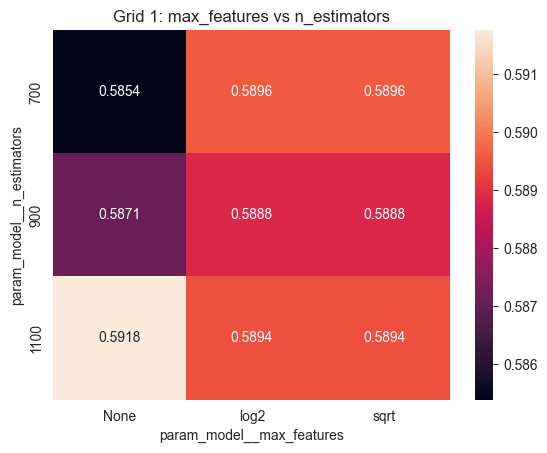

In [4]:
dt = pd.DataFrame(grid1.cv_results_)
dt.param_model__max_features = dt.param_model__max_features.astype(str)
table = pd.pivot_table(
    dt,
    values="mean_test_score",
    index="param_model__n_estimators",
    columns="param_model__max_features",
)
sns.heatmap(table, annot=True, fmt=".4f")
plt.title("Grid 1: max_features vs n_estimators")
plt.show()

### **Grid 2:** criterion & max_depth

In [5]:
param_grid2 = {
    "model__max_features": [None],
    "model__n_estimators": [1000, 1100],
    "model__criterion": ["entropy", "gini"],
    "model__max_depth": [5, 8, 10, None],
}
grid2 = GridSearchCV(build_pipeline(), param_grid2, cv=cv, scoring="f1", n_jobs=-1, verbose=1)
grid2.fit(x_train, y_train)
print("Best:", grid2.best_params_)
print("Best F1:", grid2.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': None, 'model__n_estimators': 1000}
Best F1: 0.628218043137877


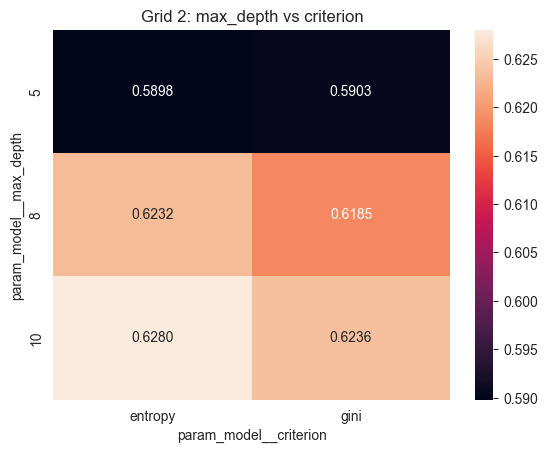

In [ ]:
dt2 = pd.DataFrame(grid2.cv_results_)
table2 = pd.pivot_table(dt2, values="mean_test_score",
    index="param_model__max_depth", columns="param_model__criterion")
sns.heatmap(table2, annot=True, fmt=".4f")
plt.title("Grid 2: max_depth vs criterion")
plt.show()

### **Grid 3:** min_samples_leaf & min_samples_split

In [7]:
param_grid3 = {
    "model__max_features": [None],
    "model__n_estimators": [1000],
    "model__criterion": ["entropy"],
    "model__max_depth": [5],
    "model__min_samples_leaf": [10, 15, 20, 30],
    "model__min_samples_split": [20, 25, 30, 40],
}
grid3 = GridSearchCV(
    build_pipeline(), param_grid3, cv=cv, scoring="f1", n_jobs=-1, verbose=1
)
grid3.fit(x_train, y_train)
print("Best:", grid3.best_params_)
print("Best F1:", grid3.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 20, 'model__min_samples_split': 20, 'model__n_estimators': 1000}
Best F1: 0.5878344655258647


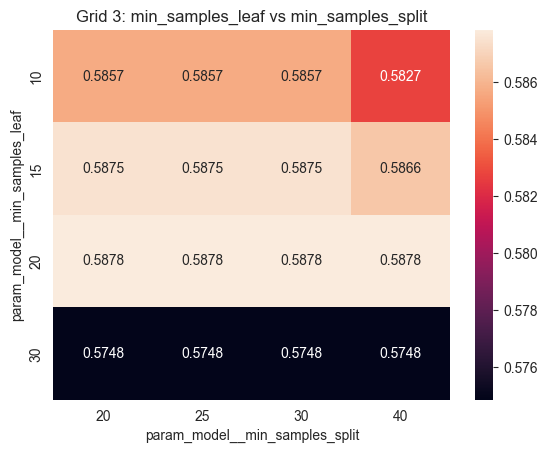

In [8]:
dt3 = pd.DataFrame(grid3.cv_results_)
table3 = pd.pivot_table(
    dt3,
    values="mean_test_score",
    index="param_model__min_samples_leaf",
    columns="param_model__min_samples_split",
)
sns.heatmap(table3, annot=True, fmt=".4f")
plt.title("Grid 3: min_samples_leaf vs min_samples_split")
plt.show()

### **Grid 4:** class_weight

In [9]:
param_grid4 = {
    "model__max_features": [None],
    "model__n_estimators": [1000],
    "model__criterion": ["entropy"],
    "model__max_depth": [5],
    "model__min_samples_leaf": [20],
    "model__min_samples_split": [30],
    "model__class_weight": [{0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}],
}
grid4 = GridSearchCV(
    build_pipeline(), param_grid4, cv=cv, scoring="f1", n_jobs=-1, verbose=1
)
grid4.fit(x_train, y_train)
print("Best:", grid4.best_params_)
print("Best F1:", grid4.best_score_)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best: {'model__class_weight': {0: 1, 1: 3}, 'model__criterion': 'entropy', 'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 20, 'model__min_samples_split': 30, 'model__n_estimators': 1000}
Best F1: 0.5891349849159989


## Final Parameters Summary

In [10]:
from src.model import BEST_PARAMS

print("Final hyperparameters used in production model:")
for k, v in BEST_PARAMS.items():
    print(f"  {k}: {v}")

Final hyperparameters used in production model:
  bootstrap: True
  ccp_alpha: 0.0
  class_weight: {0: 1, 1: 3.4}
  criterion: entropy
  max_depth: 5
  max_features: sqrt
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 20
  min_samples_split: 30
  min_weight_fraction_leaf: 0
  n_estimators: 1000
  n_jobs: -1
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False


These parameters are hardcoded in `src/model.py::BEST_PARAMS` and used by `build_pipeline()`.